In [83]:
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns
df= pd.read_csv("C:/Users/salaz/OneDrive/Desktop/Ciencia de Datos/Proyecto NFL/Data/Base de Datos Limpia")
df

,Year,Name,College,POS,Height (in),Weight (lbs),Hand Size (in),Arm Length (in),Wonderlic,40 Yard,Bench Press,Vert Leap (in),Broad Jump (in),Shuttle,3Cone,60Yd Shuttle
0,1987.0,Mike Adams,Arizona State,CB,74.00,198.0,8.50,30.50,24.0,4.42,13.0,32.0,118.0,4.60,9.99,11.65
1,1987.0,John Adickes,Florida State,C,74.00,266.0,10.25,30.00,24.0,4.80,25.0,26.5,103.0,4.60,9.99,11.65
2,1987.0,Tommy Agee,Auburn,FB,74.00,217.0,9.00,30.75,24.0,9.99,15.0,32.0,113.0,9.99,9.99,11.65
3,1987.0,David Alexander,Florida State,C,75.00,279.0,10.50,32.25,24.0,5.13,22.0,27.5,113.0,4.33,9.99,11.65
4,1987.0,Lyneal Alston,Southern Mississippi,WR,72.10,202.0,10.00,33.00,24.0,4.64,7.0,32.0,114.0,4.52,9.99,11.85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10427,2015.0,Steve Smith,Michigan State,FS,72.63,208.0,10.38,32.25,24.0,4.65,20.0,32.0,119.0,4.33,7.09,11.65
10428,2001.0,Steve Smith,Penn State,CB,72.30,199.0,8.50,31.00,24.0,4.53,20.0,34.5,113.0,4.27,7.21,11.84
10429,2014.0,James Morris,Iowa,ILB,72.88,241.0,9.13,30.75,24.0,4.80,18.0,34.5,116.0,4.36,6.94,11.65
10430,1991.0,Todd Scott,Southwestern Louisiana,CB,70.40,204.0,9.63,31.00,24.0,4.65,14.0,33.0,113.0,4.52,9.99,11.41


In [84]:
features = [
    "Height (in)", "Weight (lbs)", "40 Yard", "Bench Press",
    "Vert Leap (in)", "Broad Jump (in)", "Shuttle", "3Cone"
]

X = df[features]


In [85]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


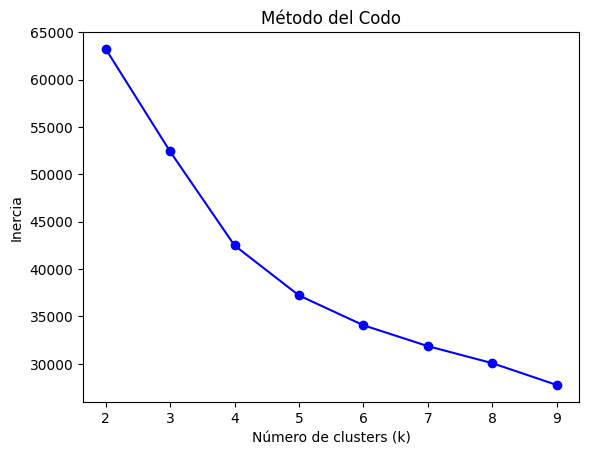

In [86]:
inertia = []
K = range(2, 10)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K, inertia, 'bo-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.show()


In [87]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)
df["Cluster"].value_counts()


Cluster
2    4091
1    3245
0    3096
Name: count, dtype: int64

In [88]:
cluster_summary = df.groupby("Cluster")[features].mean().round(2)
display(cluster_summary)


,Height (in),Weight (lbs),40 Yard,Bench Press,Vert Leap (in),Broad Jump (in),Shuttle,3Cone
Cluster,,,,,,,,
0,72.97,220.02,4.66,19.13,34.65,117.61,4.37,7.20
1,75.93,289.72,5.32,23.12,28.65,105.05,5.45,8.92
2,72.61,215.43,5.68,17.94,32.67,114.65,7.36,9.98


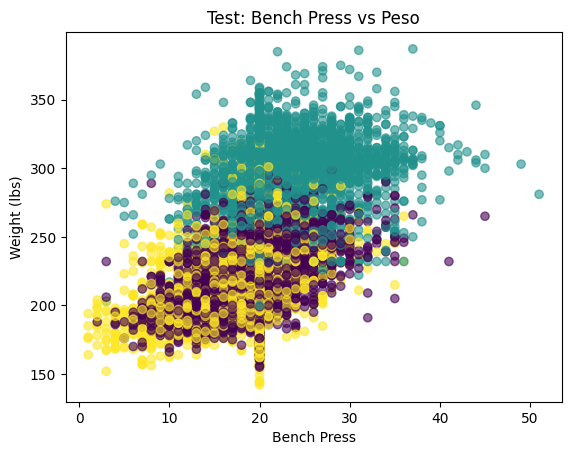

In [89]:
plt.scatter(df["Bench Press"], df["Weight (lbs)"], c=df["Cluster"], cmap="viridis", alpha=0.6)
plt.xlabel("Bench Press")
plt.ylabel("Weight (lbs)")
plt.title("Test: Bench Press vs Peso")
plt.show()
#

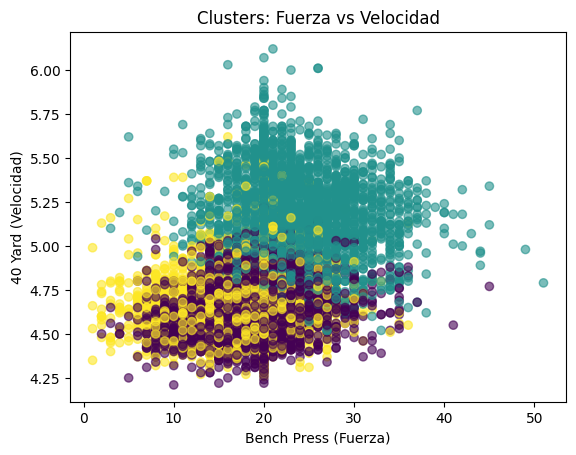

In [90]:
#Aqui tenemos en la prueba de 40 yardas me di cuenta que hay varios jugadores que tienen tiempos muy altos, 
# lo cual no es posible en la realidad, por lo que decidí eliminar esos valores atípicos para tener un análisis más preciso.
# igualmente el mejor tiempo en las 40 yardas es de 4.22 segundos, por lo que establecí un rango entre 4.0 y 7.0 segundos.
df = df[(df["40 Yard"] < 7.0) & (df["40 Yard"] > 4.0)]

plt.scatter(df["Bench Press"], df["40 Yard"], c=df["Cluster"], cmap="viridis", alpha=0.6)
plt.xlabel("Bench Press (Fuerza)")
plt.ylabel("40 Yard (Velocidad)")
plt.title("Clusters: Fuerza vs Velocidad")
plt.show()


In [91]:
#Tuve que hacer un IQR para eliminar los datos que son atipicos y que me afectan para asi mejorar el Proceso de clusterizacion
#Carggar el nuevro df
import pandas as pd
df=pd.read_csv("C:/Users/salaz/OneDrive/Desktop/Ciencia de Datos/Proyecto NFL/NFL_Csv_Cluster")
df

,Year,Name,College,POS,Height (in),Weight (lbs),Hand Size (in),Arm Length (in),Wonderlic,40 Yard,Bench Press,Vert Leap (in),Broad Jump (in),Shuttle,3Cone,60Yd Shuttle
0,1987.0,Mike Adams,Arizona State,CB,74.00,198.0,8.50,30.50,24.0,4.42,13.0,32.0,118.0,4.60,9.99,11.65
1,1987.0,John Adickes,Florida State,C,74.00,266.0,10.25,30.00,24.0,4.80,25.0,26.5,103.0,4.60,9.99,11.65
2,1987.0,David Alexander,Florida State,C,75.00,279.0,10.50,32.25,24.0,5.13,22.0,27.5,113.0,4.33,9.99,11.65
3,1987.0,Steve Alvord,Washington,DE,76.50,273.0,8.75,34.00,24.0,4.86,18.0,28.5,108.0,4.49,9.99,11.65
4,1987.0,Anthony Anderson,Grambling State (LA),CB,73.60,208.0,8.50,32.50,24.0,4.69,20.0,31.0,111.0,4.48,9.99,12.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8776,2015.0,Steve Smith,Michigan State,FS,72.63,208.0,10.38,32.25,24.0,4.65,20.0,32.0,119.0,4.33,7.09,11.65
8777,2001.0,Steve Smith,Penn State,CB,72.30,199.0,8.50,31.00,24.0,4.53,20.0,34.5,113.0,4.27,7.21,11.84
8778,2014.0,James Morris,Iowa,ILB,72.88,241.0,9.13,30.75,24.0,4.80,18.0,34.5,116.0,4.36,6.94,11.65
8779,1991.0,Todd Scott,Southwestern Louisiana,CB,70.40,204.0,9.63,31.00,24.0,4.65,14.0,33.0,113.0,4.52,9.99,11.41


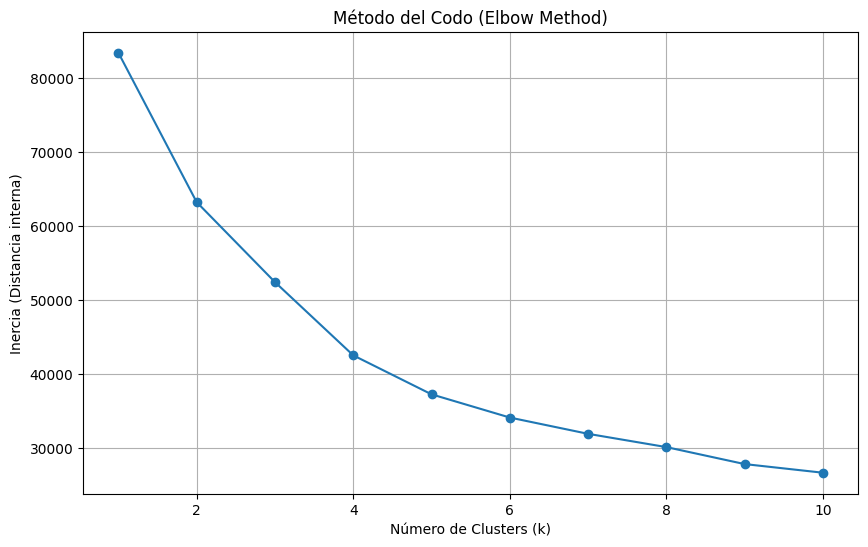

In [92]:

inertia_values = []
K_range = range(1, 11)  # probamos de 1 a 10 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(10,6))
plt.plot(K_range, inertia_values, marker='o')
plt.title("Método del Codo (Elbow Method)")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Inercia (Distancia interna)")
plt.grid(True)
plt.show()

In [93]:
cols_cluster = [#Las columnas que usare para la clusterizacion
    "40 Yard",
    "Bench Press",
    "Vert Leap (in)",
    "Broad Jump (in)",
    "Weight (lbs)",
    "Height (in)"
]

X = df[cols_cluster]
#Estandarizar 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



In [94]:
k = 4 #El el mejor valor segun la grafica anterior
kmeans = KMeans(n_clusters=k, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

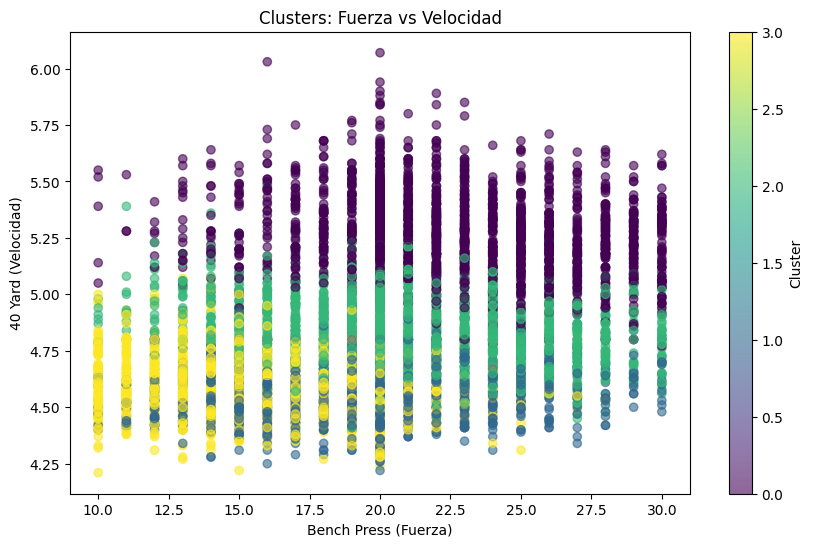

In [95]:
plt.figure(figsize=(10,6))#Velocidad vs fuera
plt.scatter(df["Bench Press"], df["40 Yard"], c=df["Cluster"], cmap="viridis", alpha=0.6)
plt.xlabel("Bench Press (Fuerza)")
plt.ylabel("40 Yard (Velocidad)")
plt.title("Clusters: Fuerza vs Velocidad")
plt.colorbar(label="Cluster")
plt.show()

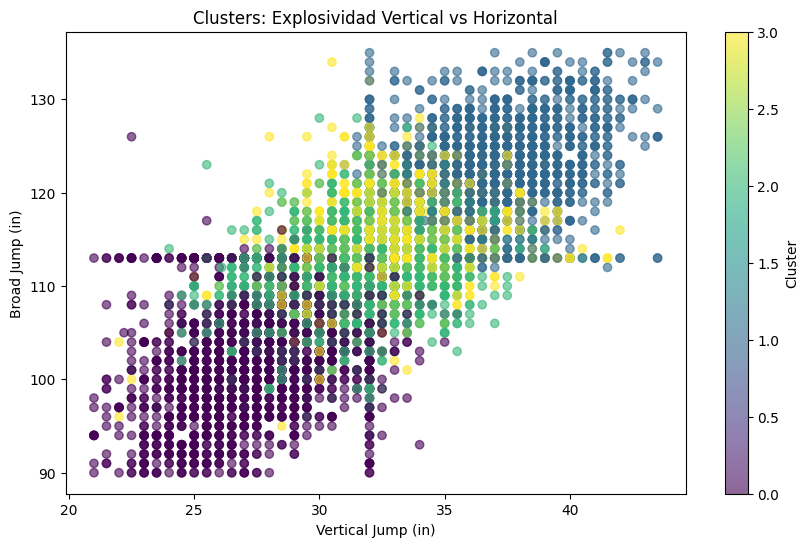

In [96]:
plt.figure(figsize=(10,6))
plt.scatter(df["Vert Leap (in)"], df["Broad Jump (in)"], c=df["Cluster"], cmap="viridis", alpha=0.6)
plt.xlabel("Vertical Jump (in)")
plt.ylabel("Broad Jump (in)")
plt.title("Clusters: Explosividad Vertical vs Horizontal")
plt.colorbar(label="Cluster")
plt.show()


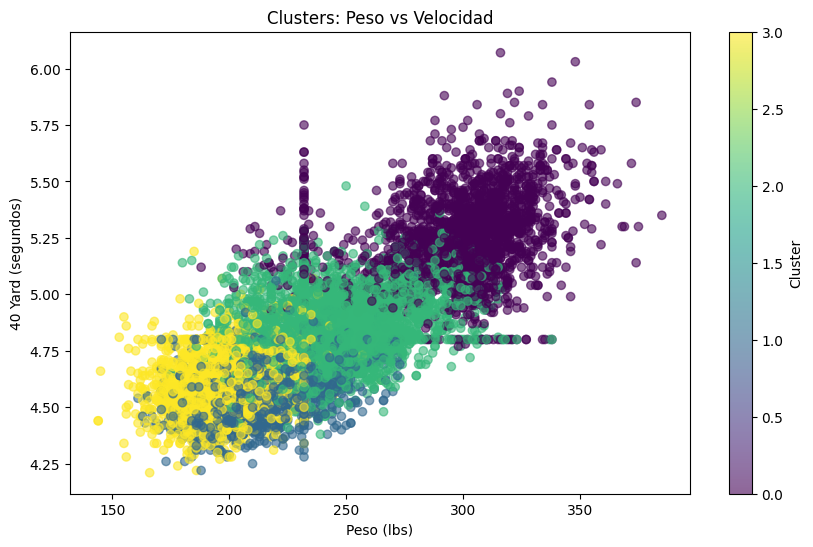

In [97]:
plt.figure(figsize=(10,6))
plt.scatter(df["Weight (lbs)"], df["40 Yard"], c=df["Cluster"], cmap="viridis", alpha=0.6)
plt.xlabel("Peso (lbs)")
plt.ylabel("40 Yard (segundos)")
plt.title("Clusters: Peso vs Velocidad")
plt.colorbar(label="Cluster")
plt.show()

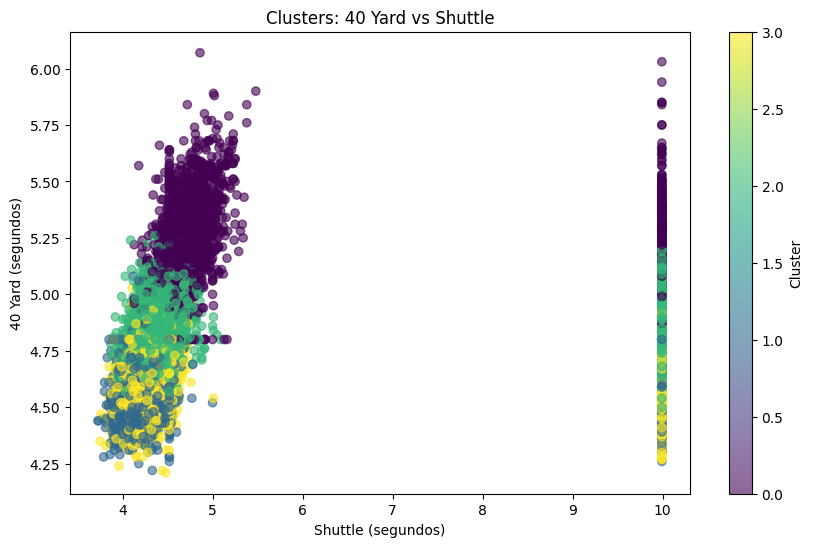

In [98]:
plt.figure(figsize=(10,6))
plt.scatter(df["Shuttle"], df["40 Yard"], c=df["Cluster"], cmap="viridis", alpha=0.6)
plt.xlabel("Shuttle (segundos)")
plt.ylabel("40 Yard (segundos)")
plt.title("Clusters: 40 Yard vs Shuttle")
plt.colorbar(label="Cluster")
plt.show()


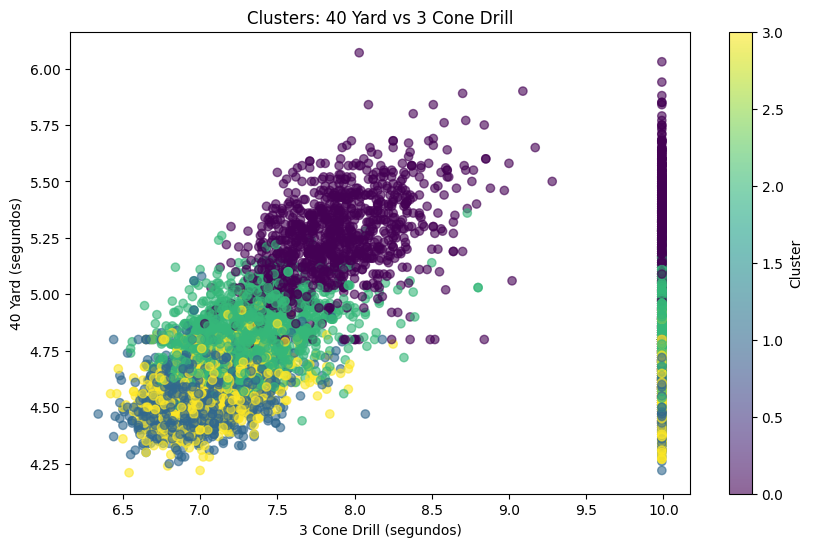

In [99]:
plt.figure(figsize=(10,6))
plt.scatter(df["3Cone"], df["40 Yard"], c=df["Cluster"], cmap="viridis", alpha=0.6)
plt.xlabel("3 Cone Drill (segundos)")
plt.ylabel("40 Yard (segundos)")
plt.title("Clusters: 40 Yard vs 3 Cone Drill")
plt.colorbar(label="Cluster")
plt.show()


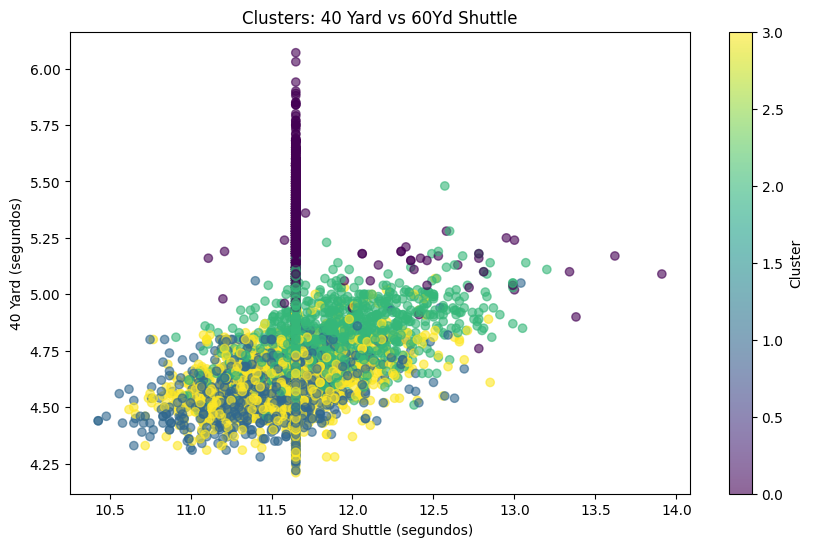

In [100]:
plt.figure(figsize=(10,6))
plt.scatter(df["60Yd Shuttle"], df["40 Yard"], c=df["Cluster"], cmap="viridis", alpha=0.6)
plt.xlabel("60 Yard Shuttle (segundos)")
plt.ylabel("40 Yard (segundos)")
plt.title("Clusters: 40 Yard vs 60Yd Shuttle")
plt.colorbar(label="Cluster")
plt.show()


In [101]:
#Tuve problema de nuevo con los datos atipicos
df = df[df["Shuttle"] < 7]       
df = df[df["3Cone"] < 9]         
df = df[df["60Yd Shuttle"] > 11] 

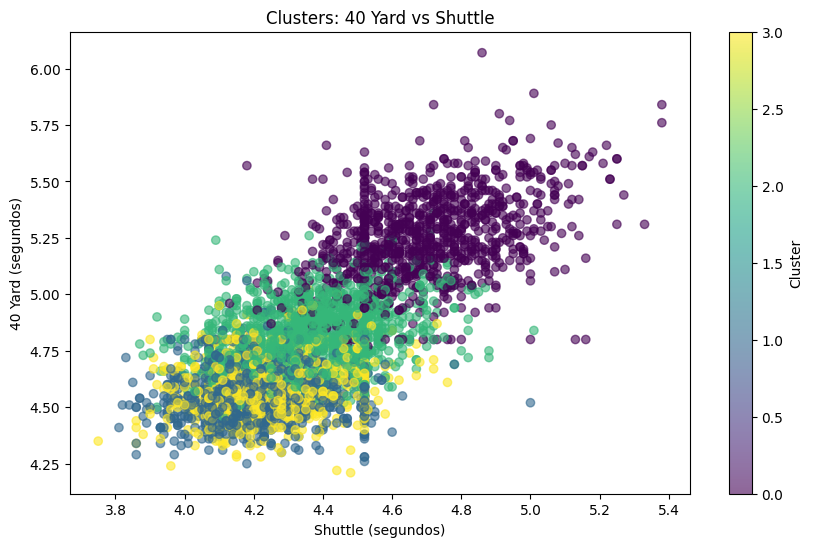

In [102]:
plt.figure(figsize=(10,6))
plt.scatter(df["Shuttle"], df["40 Yard"], c=df["Cluster"], cmap="viridis", alpha=0.6)
plt.xlabel("Shuttle (segundos)")
plt.ylabel("40 Yard (segundos)")
plt.title("Clusters: 40 Yard vs Shuttle")
plt.colorbar(label="Cluster")
plt.show()

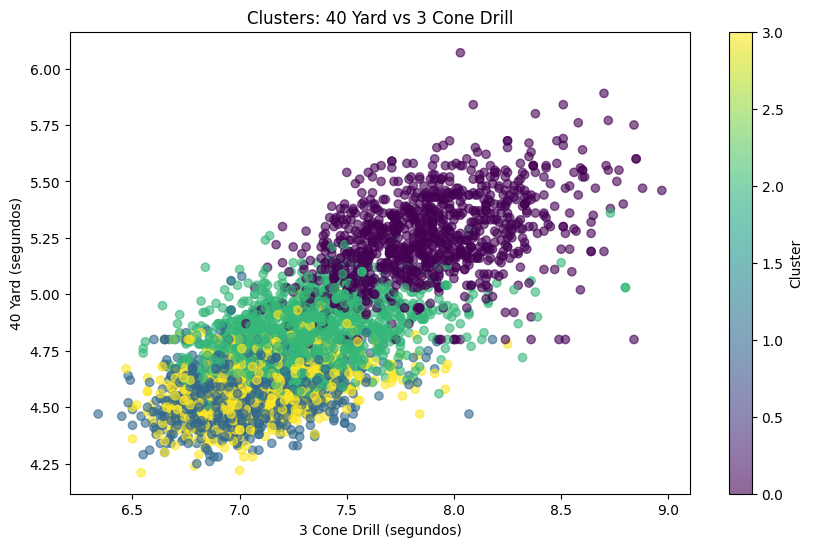

In [103]:
plt.figure(figsize=(10,6))
plt.scatter(df["3Cone"], df["40 Yard"], c=df["Cluster"], cmap="viridis", alpha=0.6)
plt.xlabel("3 Cone Drill (segundos)")
plt.ylabel("40 Yard (segundos)")
plt.title("Clusters: 40 Yard vs 3 Cone Drill")
plt.colorbar(label="Cluster")
plt.show()


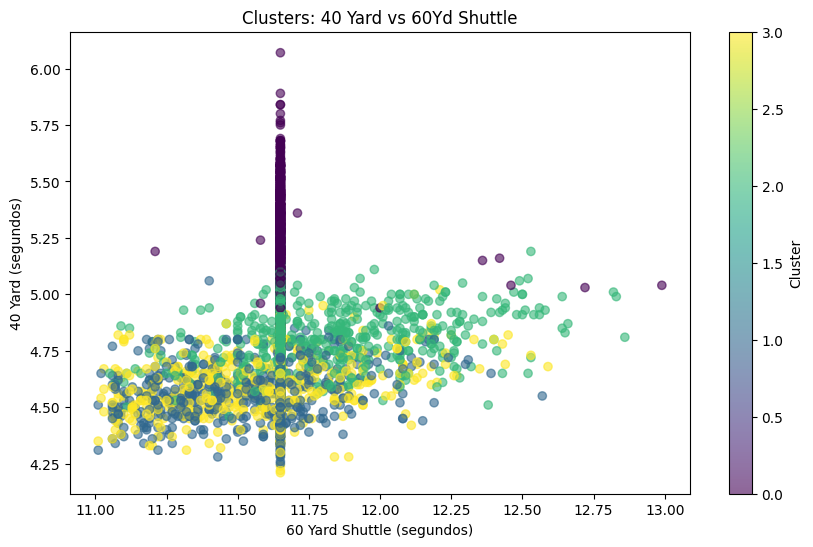

In [104]:
plt.figure(figsize=(10,6))
plt.scatter(df["60Yd Shuttle"], df["40 Yard"], c=df["Cluster"], cmap="viridis", alpha=0.6)
plt.xlabel("60 Yard Shuttle (segundos)")
plt.ylabel("40 Yard (segundos)")
plt.title("Clusters: 40 Yard vs 60Yd Shuttle")
plt.colorbar(label="Cluster")
plt.show()

Información de los Clusters

In [105]:
# Distribución general de posiciones por cluster
pos_cluster = df.groupby(["Cluster", "POS"]).size().unstack(fill_value=0)
pos_cluster


POS,C,CB,DB,DE,DL,DT,FB,FS,G,ILB,LB,OG,OL,OLB,OT,QB,RB,SS,TE,WR
Cluster,,,,,,,,,,,,,,,,,,,,
0,109,0,0,41,0,210,1,0,11,1,0,238,1,1,302,18,0,0,13,35
1,0,122,2,27,1,1,16,86,0,31,2,0,0,107,0,34,115,63,27,280
2,4,3,0,283,2,55,63,8,1,136,0,7,0,168,15,235,23,5,209,94
3,0,212,1,0,0,0,20,70,0,8,1,0,0,22,0,12,203,58,1,217


In [106]:
porcentaje_cluster = pos_cluster.div(pos_cluster.sum(axis=1), axis=0) * 100
porcentaje_cluster.round(1) #Porcentaje por pocision en cada cluster

POS,C,CB,DB,DE,DL,DT,FB,FS,G,ILB,LB,OG,OL,OLB,OT,QB,RB,SS,TE,WR
Cluster,,,,,,,,,,,,,,,,,,,,
0,11.1,0.0,0.0,4.2,0.0,21.4,0.1,0.0,1.1,0.1,0.0,24.3,0.1,0.1,30.8,1.8,0.0,0.0,1.3,3.6
1,0.0,13.3,0.2,3.0,0.1,0.1,1.8,9.4,0.0,3.4,0.2,0.0,0.0,11.7,0.0,3.7,12.6,6.9,3.0,30.6
2,0.3,0.2,0.0,21.6,0.2,4.2,4.8,0.6,0.1,10.4,0.0,0.5,0.0,12.8,1.1,17.9,1.8,0.4,15.9,7.2
3,0.0,25.7,0.1,0.0,0.0,0.0,2.4,8.5,0.0,1.0,0.1,0.0,0.0,2.7,0.0,1.5,24.6,7.0,0.1,26.3


In [107]:
pos_por_cluster = df.groupby("POS")["Cluster"].value_counts(normalize=True).mul(100).rename("Porcentaje").reset_index()
pos_por_cluster

,POS,Cluster,Porcentaje
0,C,0,96.460177
1,C,2,3.539823
2,CB,3,62.908012
3,CB,1,36.201780
4,CB,2,0.890208
5,DB,1,66.666667
6,DB,3,33.333333
7,DE,2,80.626781
8,DE,0,11.680912
9,DE,1,7.692308


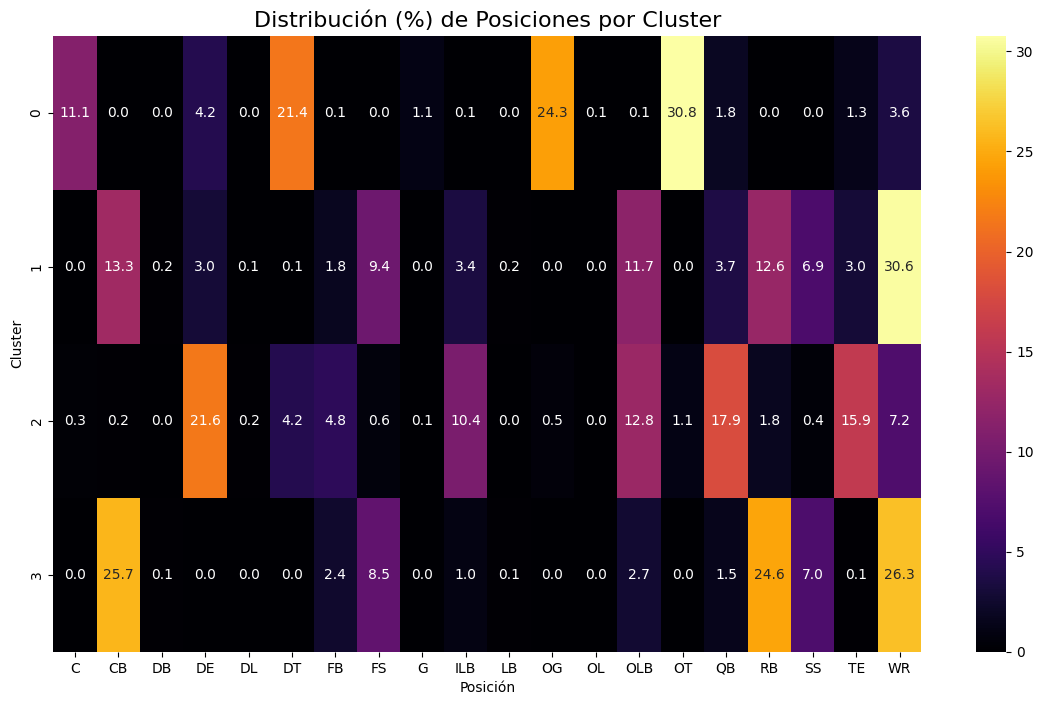

In [108]:
plt.figure(figsize=(14, 8))
sns.heatmap(porcentaje_cluster, annot=True, cmap="inferno", fmt=".1f")
plt.title("Distribución (%) de Posiciones por Cluster", fontsize=16)
plt.xlabel("Posición")
plt.ylabel("Cluster")
plt.show()

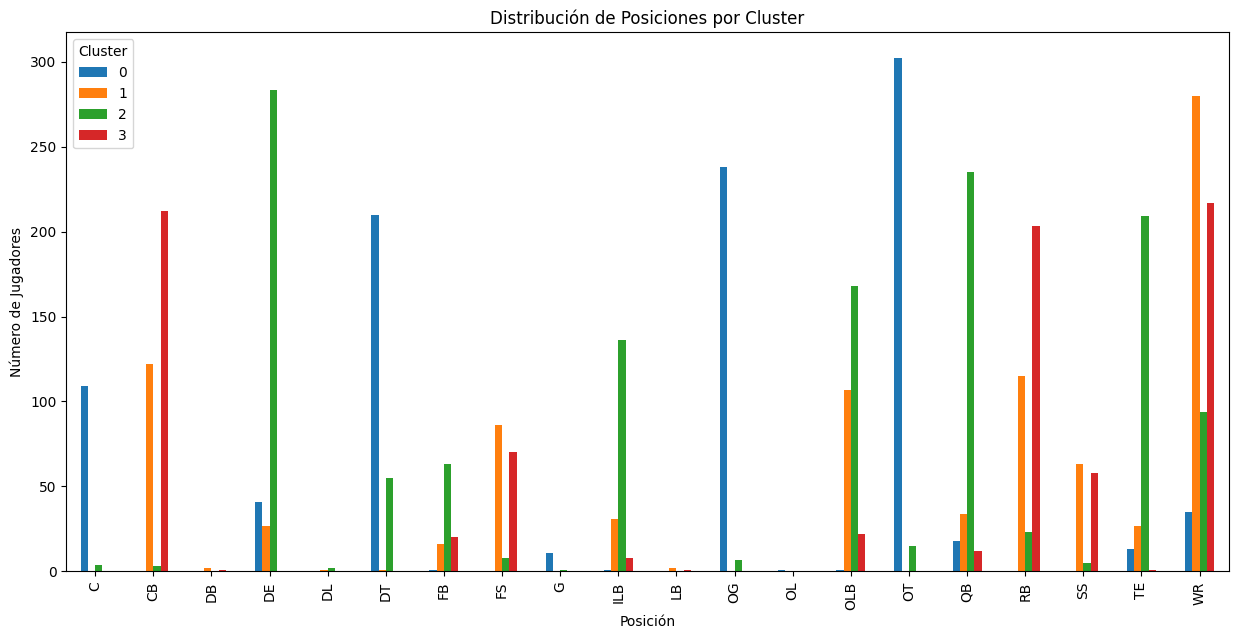

In [109]:
pos_cluster.T.plot(kind="bar", figsize=(15,7))
plt.title("Distribución de Posiciones por Cluster")
plt.ylabel("Número de Jugadores")
plt.xlabel("Posición")
plt.legend(title="Cluster")
plt.show()

In [110]:
# Hago una familia por pocisiones similares
Familia = {
    "C": "OL",
    "G": "OL",
    "OG": "OL",
    "OL": "OL",
    "OT": "OL",
    
    "DE": "DL",
    "DL": "DL",
    "DT": "DL",
    
    "LB": "LB",
    "ILB": "LB",
    "OLB": "LB",
    
    "CB": "DB",
    "DB": "DB",
    "FS": "DB",
    "SS": "DB",
    
    "WR": "WR/TE",
    "TE": "WR/TE",
    
    "RB": "RB/FB",
    "FB": "RB/FB",
    
    "QB": "QB",
}

df["Pastel"] = df["POS"].map(Familia).fillna("Otros")

df[["POS", "Pastel"]].head()


,POS,Pastel
2494,WR,WR/TE
2495,OT,OL
2496,ILB,LB
2497,FS,DB
2498,TE,WR/TE


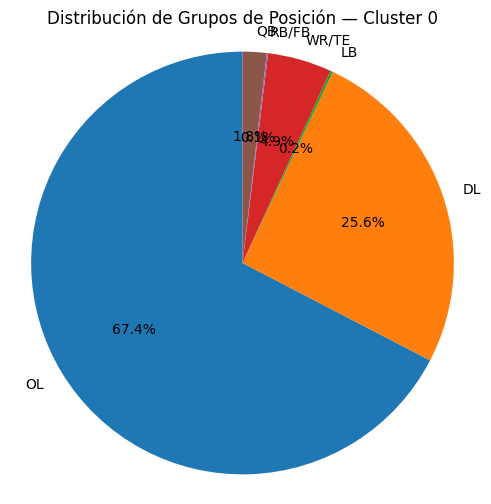

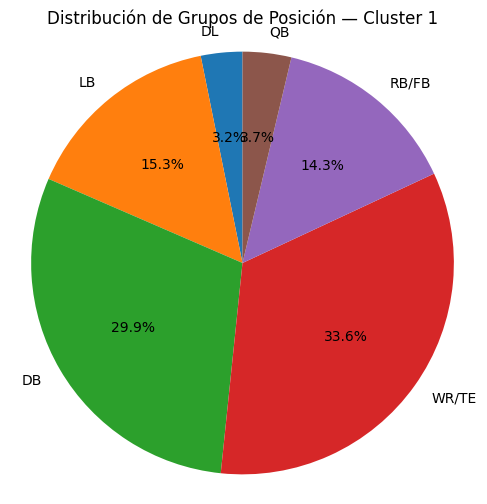

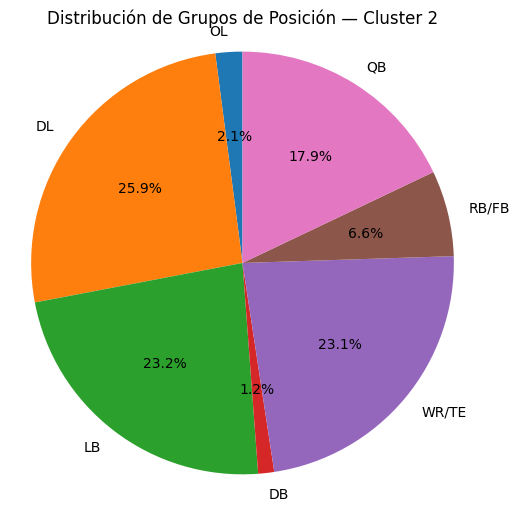

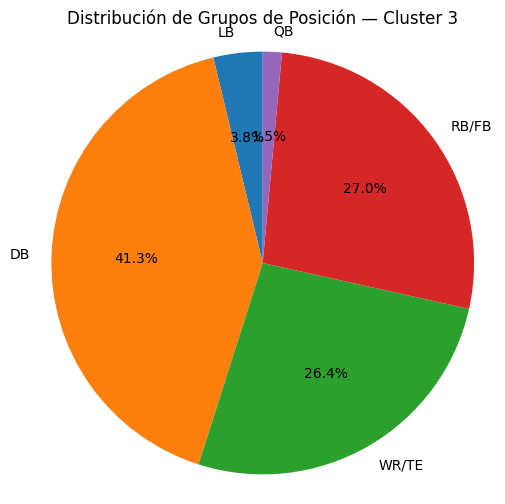

In [ ]:
import matplotlib.pyplot as plt

clusters = sorted(df["Cluster"].unique())
groups_order = ["OL", "DL", "LB", "DB", "WR/TE", "RB/FB", "QB", "Otros"]

for i in clusters:
    sub = df[df["Cluster"] == i]
    counts = sub["Pastel"].value_counts()
    # reordenar según nuestro orden predefinido
    counts = counts.reindex(groups_order).dropna()

    plt.figure(figsize=(6,6))
    plt.pie(
        counts.values,
        labels=counts.index,
        autopct="%1.1f%%",
        startangle=90
    )
    plt.title(f"Distribución de Grupos de Posición — Cluster {i}")
    plt.axis("equal")  # para que el pastel sea circular
    plt.show()
